# Cohort Overview and Demographics

This notebook provides comprehensive overview of the colorectal cancer patient cohort.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

plt.style.use('default')
sns.set_palette('Set2')
primary_green = '#2E8B57'
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
patient_metadata = pd.read_csv('../results/cohort_demographics/patient_metadata.tsv', sep='\t')
cohort_summary = pd.read_csv('../results/cohort_demographics/cohort_summary.csv')
age_distribution = pd.read_csv('../results/cohort_demographics/age_distribution.csv')

print(f'Patient metadata shape: {patient_metadata.shape}')
print(f'Cohort summary shape: {cohort_summary.shape}')
print(f'Age distribution shape: {age_distribution.shape}')

Patient metadata shape: (219, 13)
Cohort summary shape: (21, 3)
Age distribution shape: (12, 3)


## Summary Statistics

In [3]:
print('\n=== COHORT SUMMARY STATISTICS ===')
print(cohort_summary.to_string(index=False))

n_total = patient_metadata.shape[0]
n_coad = (patient_metadata['cohort'] == 'COAD').sum()
n_read = (patient_metadata['cohort'] == 'READ').sum()
n_metabo = patient_metadata['has_metabolomics'].sum()

print(f'\n=== KEY METRICS ===')
print(f'Total patients: {n_total}')
print(f'  COAD: {n_coad} ({100*n_coad/n_total:.1f}%)')
print(f'  READ: {n_read} ({100*n_read/n_total:.1f}%)')
print(f'Metabolomics data available: {n_metabo}/{n_total} ({100*n_metabo/n_total:.1f}%)')


=== COHORT SUMMARY STATISTICS ===
        Category  Count  Percentage
  Total patients    219  100.000000
            COAD    155   70.776256
            READ     64   29.223744
            Male    114   52.054795
          Female    105   47.945205
         Stage I     34   15.525114
        Stage II     71   32.420091
       Stage III     68   31.050228
        Stage IV     37   16.894977
   Unknown stage      9    4.109589
             MSS    152   69.406393
           MSI-H     52   23.744292
           MSI-L     15    6.849315
Has metabolomics     96   43.835616
 No metabolomics    123   56.164384
       OS events     80   36.529680
     OS censored    139   63.470320
      OS missing     11    5.022831
      DFS events     95   43.378995
    DFS censored     92   42.009132
     DFS missing     32   14.611872

=== KEY METRICS ===
Total patients: 219
  COAD: 155 (70.8%)
  READ: 64 (29.2%)
Metabolomics data available: 96/219 (43.8%)


## Figure 1: Cohort Overview (2x2 Subplots)

/sessions/beautiful-dreamy-ride/tmp/ipykernel_2842/773838492.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


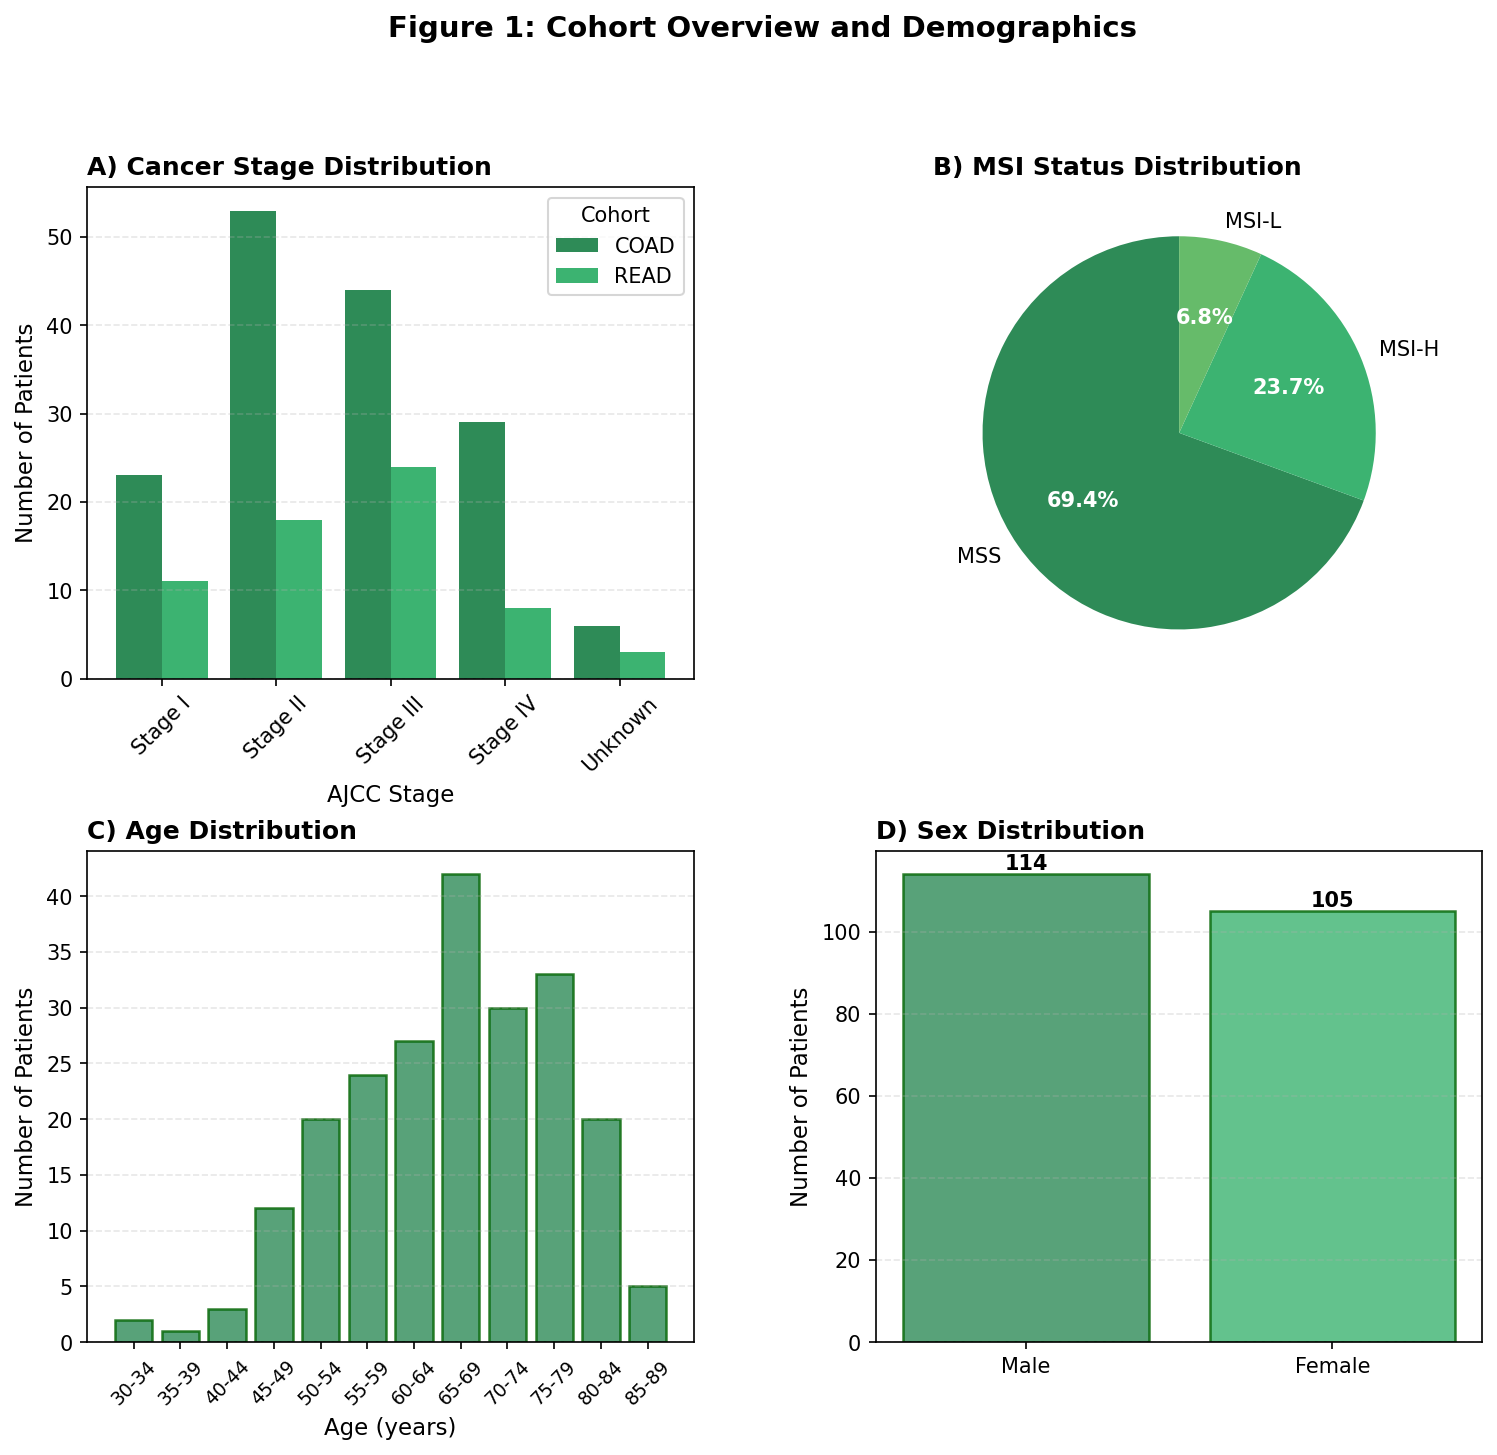

Figure 1 saved as Figure_1_Cohort_Overview.png


In [4]:
fig = plt.figure(figsize=(12, 10), dpi=150)
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Panel A: Stage distribution
ax_a = fig.add_subplot(gs[0, 0])
stage_cohort_data = pd.crosstab(patient_metadata['ajcc_stage'], patient_metadata['cohort'])
stage_cohort_data = stage_cohort_data[['COAD', 'READ']]
stage_cohort_data.plot(kind='bar', ax=ax_a, color=['#2E8B57', '#3CB371'], width=0.8)
ax_a.set_title('A) Cancer Stage Distribution', fontsize=12, fontweight='bold', loc='left')
ax_a.set_xlabel('AJCC Stage', fontsize=11)
ax_a.set_ylabel('Number of Patients', fontsize=11)
ax_a.legend(title='Cohort', frameon=True, fontsize=10)
ax_a.grid(axis='y', alpha=0.3, linestyle='--')
ax_a.tick_params(axis='x', rotation=45)

# Panel B: MSI status
ax_b = fig.add_subplot(gs[0, 1])
msi_counts = patient_metadata['msi_status'].value_counts()
msi_order = ['MSS', 'MSI-H', 'MSI-L']
msi_counts = msi_counts.reindex(msi_order)
colors_msi = ['#2E8B57', '#3CB371', '#66BB6A']
wedges, texts, autotexts = ax_b.pie(msi_counts, labels=msi_counts.index, autopct='%1.1f%%', colors=colors_msi, startangle=90, textprops={'fontsize': 10})
ax_b.set_title('B) MSI Status Distribution', fontsize=12, fontweight='bold', loc='left')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Panel C: Age distribution
ax_c = fig.add_subplot(gs[1, 0])
ax_c.bar(range(len(age_distribution)), age_distribution['count'].values, color=primary_green, alpha=0.8, edgecolor='darkgreen', linewidth=1.2)
ax_c.set_xticks(range(len(age_distribution)))
ax_c.set_xticklabels(age_distribution['age_bin'].values, rotation=45, fontsize=9)
ax_c.set_title('C) Age Distribution', fontsize=12, fontweight='bold', loc='left')
ax_c.set_xlabel('Age (years)', fontsize=11)
ax_c.set_ylabel('Number of Patients', fontsize=11)
ax_c.grid(axis='y', alpha=0.3, linestyle='--')

# Panel D: Sex distribution
ax_d = fig.add_subplot(gs[1, 1])
sex_counts = patient_metadata['sex'].value_counts()
sex_labels = ['Male' if x == 'M' else 'Female' for x in sex_counts.index]
sex_colors = ['#2E8B57', '#3CB371']
bars = ax_d.bar(sex_labels, sex_counts.values, color=sex_colors, alpha=0.8, edgecolor='darkgreen', linewidth=1.2)
ax_d.set_title('D) Sex Distribution', fontsize=12, fontweight='bold', loc='left')
ax_d.set_ylabel('Number of Patients', fontsize=11)
ax_d.grid(axis='y', alpha=0.3, linestyle='--')
for bar in bars:
    height = bar.get_height()
    ax_d.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Figure 1: Cohort Overview and Demographics', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('Figure_1_Cohort_Overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved as Figure_1_Cohort_Overview.png')

## Survival and Metabolomics Summary

In [5]:
print('\n=== OVERALL SURVIVAL SUMMARY ===')
os_data = patient_metadata[patient_metadata['os_days'] > 0].copy()
os_events = os_data[os_data['os_event'] == 1]
print(f'Patients with OS data: {len(os_data)}/{n_total}')
print(f'OS Events: {len(os_events)} ({100*len(os_events)/len(os_data):.1f}%)')
print(f'Median OS: {os_data["os_days"].median():.0f} days ({os_data["os_days"].median()/365.25:.1f} years)')

print('\n=== DISEASE-FREE SURVIVAL SUMMARY ===')
dfs_data = patient_metadata[(patient_metadata['dfs_days'] > 0) & (patient_metadata['dfs_event'] >= 0)].copy()
dfs_events = dfs_data[dfs_data['dfs_event'] == 1]
print(f'Patients with DFS data: {len(dfs_data)}/{n_total}')
print(f'DFS Events: {len(dfs_events)} ({100*len(dfs_events)/len(dfs_data):.1f}%)')
print(f'Median DFS: {dfs_data["dfs_days"].median():.0f} days ({dfs_data["dfs_days"].median()/365.25:.1f} years)')

print('\n=== METABOLOMICS DATA AVAILABILITY ===')
metabo_coad = patient_metadata[(patient_metadata['cohort'] == 'COAD') & (patient_metadata['has_metabolomics'] == 1)].shape[0]
metabo_read = patient_metadata[(patient_metadata['cohort'] == 'READ') & (patient_metadata['has_metabolomics'] == 1)].shape[0]
print(f'Total patients with metabolomics: {n_metabo}/{n_total} ({100*n_metabo/n_total:.1f}%)')
print(f'COAD: {metabo_coad}/{n_coad} ({100*metabo_coad/n_coad:.1f}%)')
print(f'READ: {metabo_read}/{n_read} ({100*metabo_read/n_read:.1f}%)')


=== OVERALL SURVIVAL SUMMARY ===
Patients with OS data: 219/219
OS Events: 80 (36.5%)
Median OS: 981 days (2.7 years)

=== DISEASE-FREE SURVIVAL SUMMARY ===
Patients with DFS data: 187/219
DFS Events: 95 (50.8%)
Median DFS: 583 days (1.6 years)

=== METABOLOMICS DATA AVAILABILITY ===
Total patients with metabolomics: 96/219 (43.8%)
COAD: 68/155 (43.9%)
READ: 28/64 (43.8%)
